In [91]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import opendatasets as od
import os
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
od.download("https://www.kaggle.com/datasets/muhamedyoussry/fertility-data-set")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  naren13


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/muhamedyoussry/fertility-data-set


100%|█████████████████████████████████████████████████████████████████████████████| 1.08k/1.08k [00:00<00:00, 97.3kB/s]

In [5]:
fr=pd.read_csv(r"fertility-data-set/fertility.csv")

In [6]:
fr.head()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal
1,spring,35,yes,no,yes,more than 3 months ago,once a week,daily,6,Altered
2,spring,27,yes,no,no,more than 3 months ago,hardly ever or never,never,9,Normal
3,spring,32,no,yes,yes,more than 3 months ago,hardly ever or never,never,7,Normal
4,spring,30,yes,yes,no,more than 3 months ago,once a week,never,9,Altered


# Data Analysis

In [7]:
fr.shape

(100, 10)

In [8]:
fr.isna().sum()

Season                                   0
Age                                      0
Childish diseases                        0
Accident or serious trauma               0
Surgical intervention                    0
High fevers in the last year             0
Frequency of alcohol consumption         0
Smoking habit                            0
Number of hours spent sitting per day    0
Diagnosis                                0
dtype: int64

In [11]:
fr.duplicated().sum()

np.int64(1)

In [13]:
fr.drop_duplicates(inplace=True)

# Data Corection

In [15]:
print(fr['Season'].unique())
print()
print(fr['Season'].value_counts())

['spring' 'fall' 'winter' 'summer']

Season
spring    37
fall      30
winter    28
summer     4
Name: count, dtype: int64


In [20]:
le=LabelEncoder()

In [21]:
fr['Season']=le.fit_transform(fr['Season'])

In [22]:
print(fr['Childish diseases'].value_counts())

Childish diseases
yes    87
no     12
Name: count, dtype: int64


In [23]:
fr['Childish diseases']=le.fit_transform(fr['Childish diseases'])

In [24]:
print(fr['Accident or serious trauma'].value_counts())

Accident or serious trauma
no     55
yes    44
Name: count, dtype: int64


In [25]:
fr['Accident or serious trauma']=le.fit_transform(fr['Accident or serious trauma'])

In [26]:
print(fr['Surgical intervention'].value_counts())

Surgical intervention
yes    50
no     49
Name: count, dtype: int64


In [27]:
fr['Surgical intervention']=le.fit_transform(fr['Surgical intervention'])

In [28]:
print(fr['High fevers in the last year'].unique())
print()
print(fr['High fevers in the last year'].value_counts())

['more than 3 months ago' 'less than 3 months ago' 'no']

High fevers in the last year
more than 3 months ago    62
no                        28
less than 3 months ago     9
Name: count, dtype: int64


In [30]:
fr['High fevers in the last year']=le.fit_transform(fr['High fevers in the last year'])

In [31]:
print(fr['Frequency of alcohol consumption'].unique())
print()
print(fr['Frequency of alcohol consumption'].value_counts())

['once a week' 'hardly ever or never' 'several times a week'
 'several times a day' 'every day']

Frequency of alcohol consumption
hardly ever or never    40
once a week             38
several times a week    19
several times a day      1
every day                1
Name: count, dtype: int64


In [32]:
fr['Frequency of alcohol consumption']=le.fit_transform(fr['Frequency of alcohol consumption'])

In [33]:
print(fr['Smoking habit'].unique())
print()
print(fr['Smoking habit'].value_counts())

['occasional' 'daily' 'never']

Smoking habit
never         55
occasional    23
daily         21
Name: count, dtype: int64


In [34]:
fr['Smoking habit']=le.fit_transform(fr['Smoking habit'])

In [36]:
print(fr['Diagnosis'].value_counts())

Diagnosis
Normal     87
Altered    12
Name: count, dtype: int64


In [37]:
fr['Diagnosis']=le.fit_transform(fr['Diagnosis'])

In [38]:
fr.head()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,1,30,0,1,1,1,2,2,16,1
1,1,35,1,0,1,1,2,0,6,0
2,1,27,1,0,0,1,1,1,9,1
3,1,32,0,1,1,1,1,1,7,1
4,1,30,1,1,0,1,2,1,9,0


In [45]:
df=fr
fr.describe()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,1.303030,30.111111,0.878788,0.444444,0.505051,1.191919,1.969697,1.020202,10.858586,0.878788
std,1.181961,2.258268,0.328035,0.499433,0.502519,0.583389,1.110750,0.669752,33.782924,0.328035
min,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,28.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000
50%,1.000000,30.000000,1.000000,0.000000,1.000000,1.000000,2.000000,1.000000,7.000000,1.000000
75%,3.000000,32.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,9.000000,1.000000
max,3.000000,36.000000,1.000000,1.000000,1.000000,2.000000,4.000000,2.000000,342.000000,1.000000


# Data Visualization

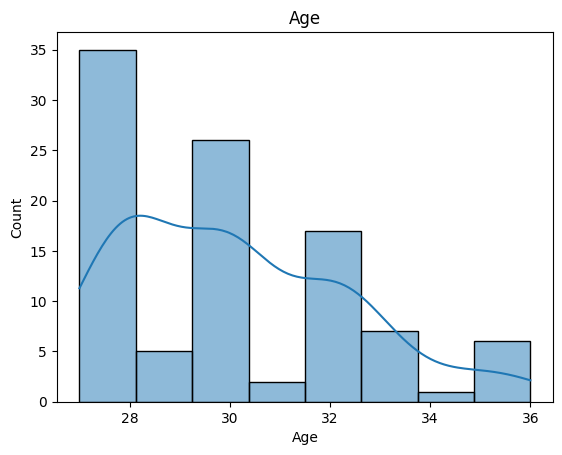

0.6676167907868729


In [42]:
sns.histplot(data=fr,x='Age',kde=True)
plt.title("Age")
plt.show()
print(fr['Age'].skew())

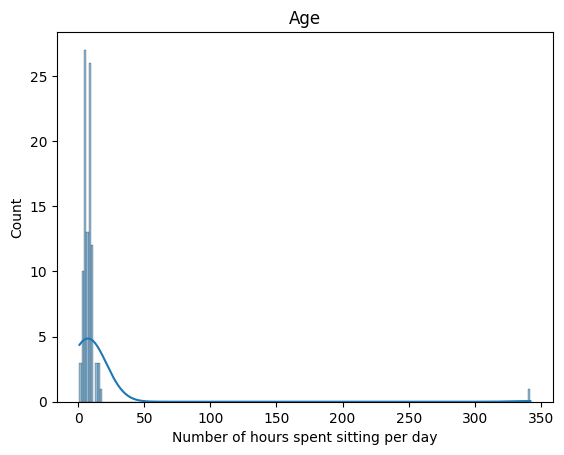

In [46]:
sns.histplot(data=fr,x='Number of hours spent sitting per day',kde=True)
plt.title("Age")
plt.show()
#print(fr['Age'].skew())

In [49]:
print("min",fr['Number of hours spent sitting per day'].min())
print("min",fr['Number of hours spent sitting per day'].max())
print((fr['Number of hours spent sitting per day']>24).sum())
fr=fr[fr['Number of hours spent sitting per day']<=24]

min 1
min 342
1


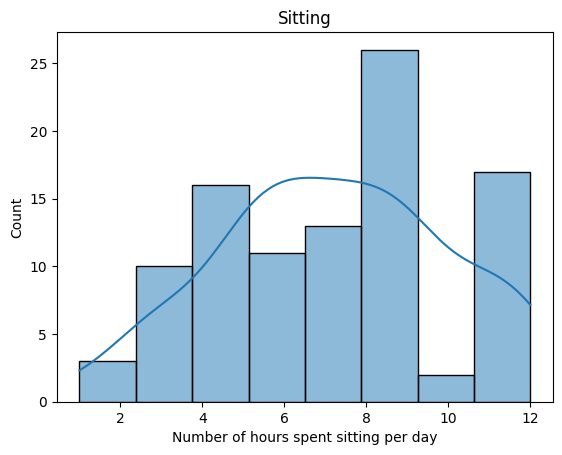

In [65]:
sns.histplot(data=fr,x='Number of hours spent sitting per day',kde=True)
plt.title("Sitting")
plt.show()
#print(fr['Age'].skew())

In [58]:
(fr['Number of hours spent sitting per day']>13).sum()

np.int64(7)

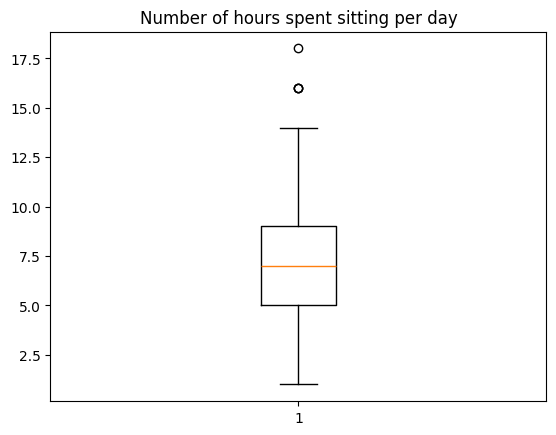

In [55]:
plt.boxplot(fr['Number of hours spent sitting per day'])
plt.title("Number of hours spent sitting per day")
plt.show()

In [63]:
fr.loc[fr['Number of hours spent sitting per day']>13,"Number of hours spent sitting per day"]=12

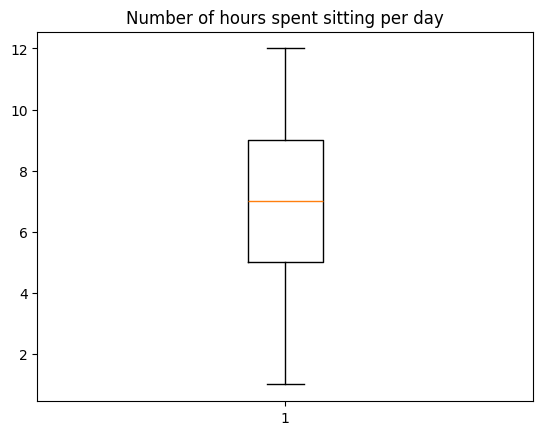

In [64]:
plt.boxplot(fr['Number of hours spent sitting per day'])
plt.title("Number of hours spent sitting per day")
plt.show()

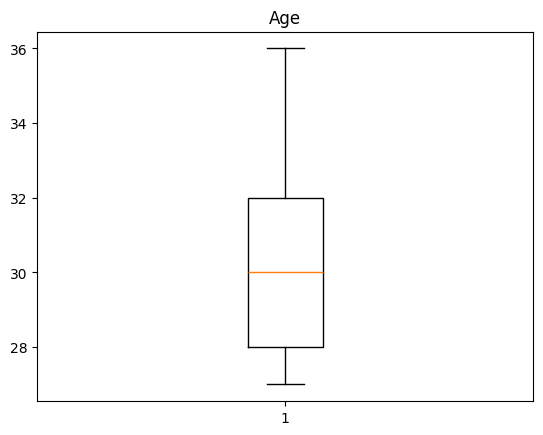

In [67]:
plt.boxplot(fr['Age'])
plt.title("Age")
plt.show()

<Figure size 2000x1500 with 0 Axes>

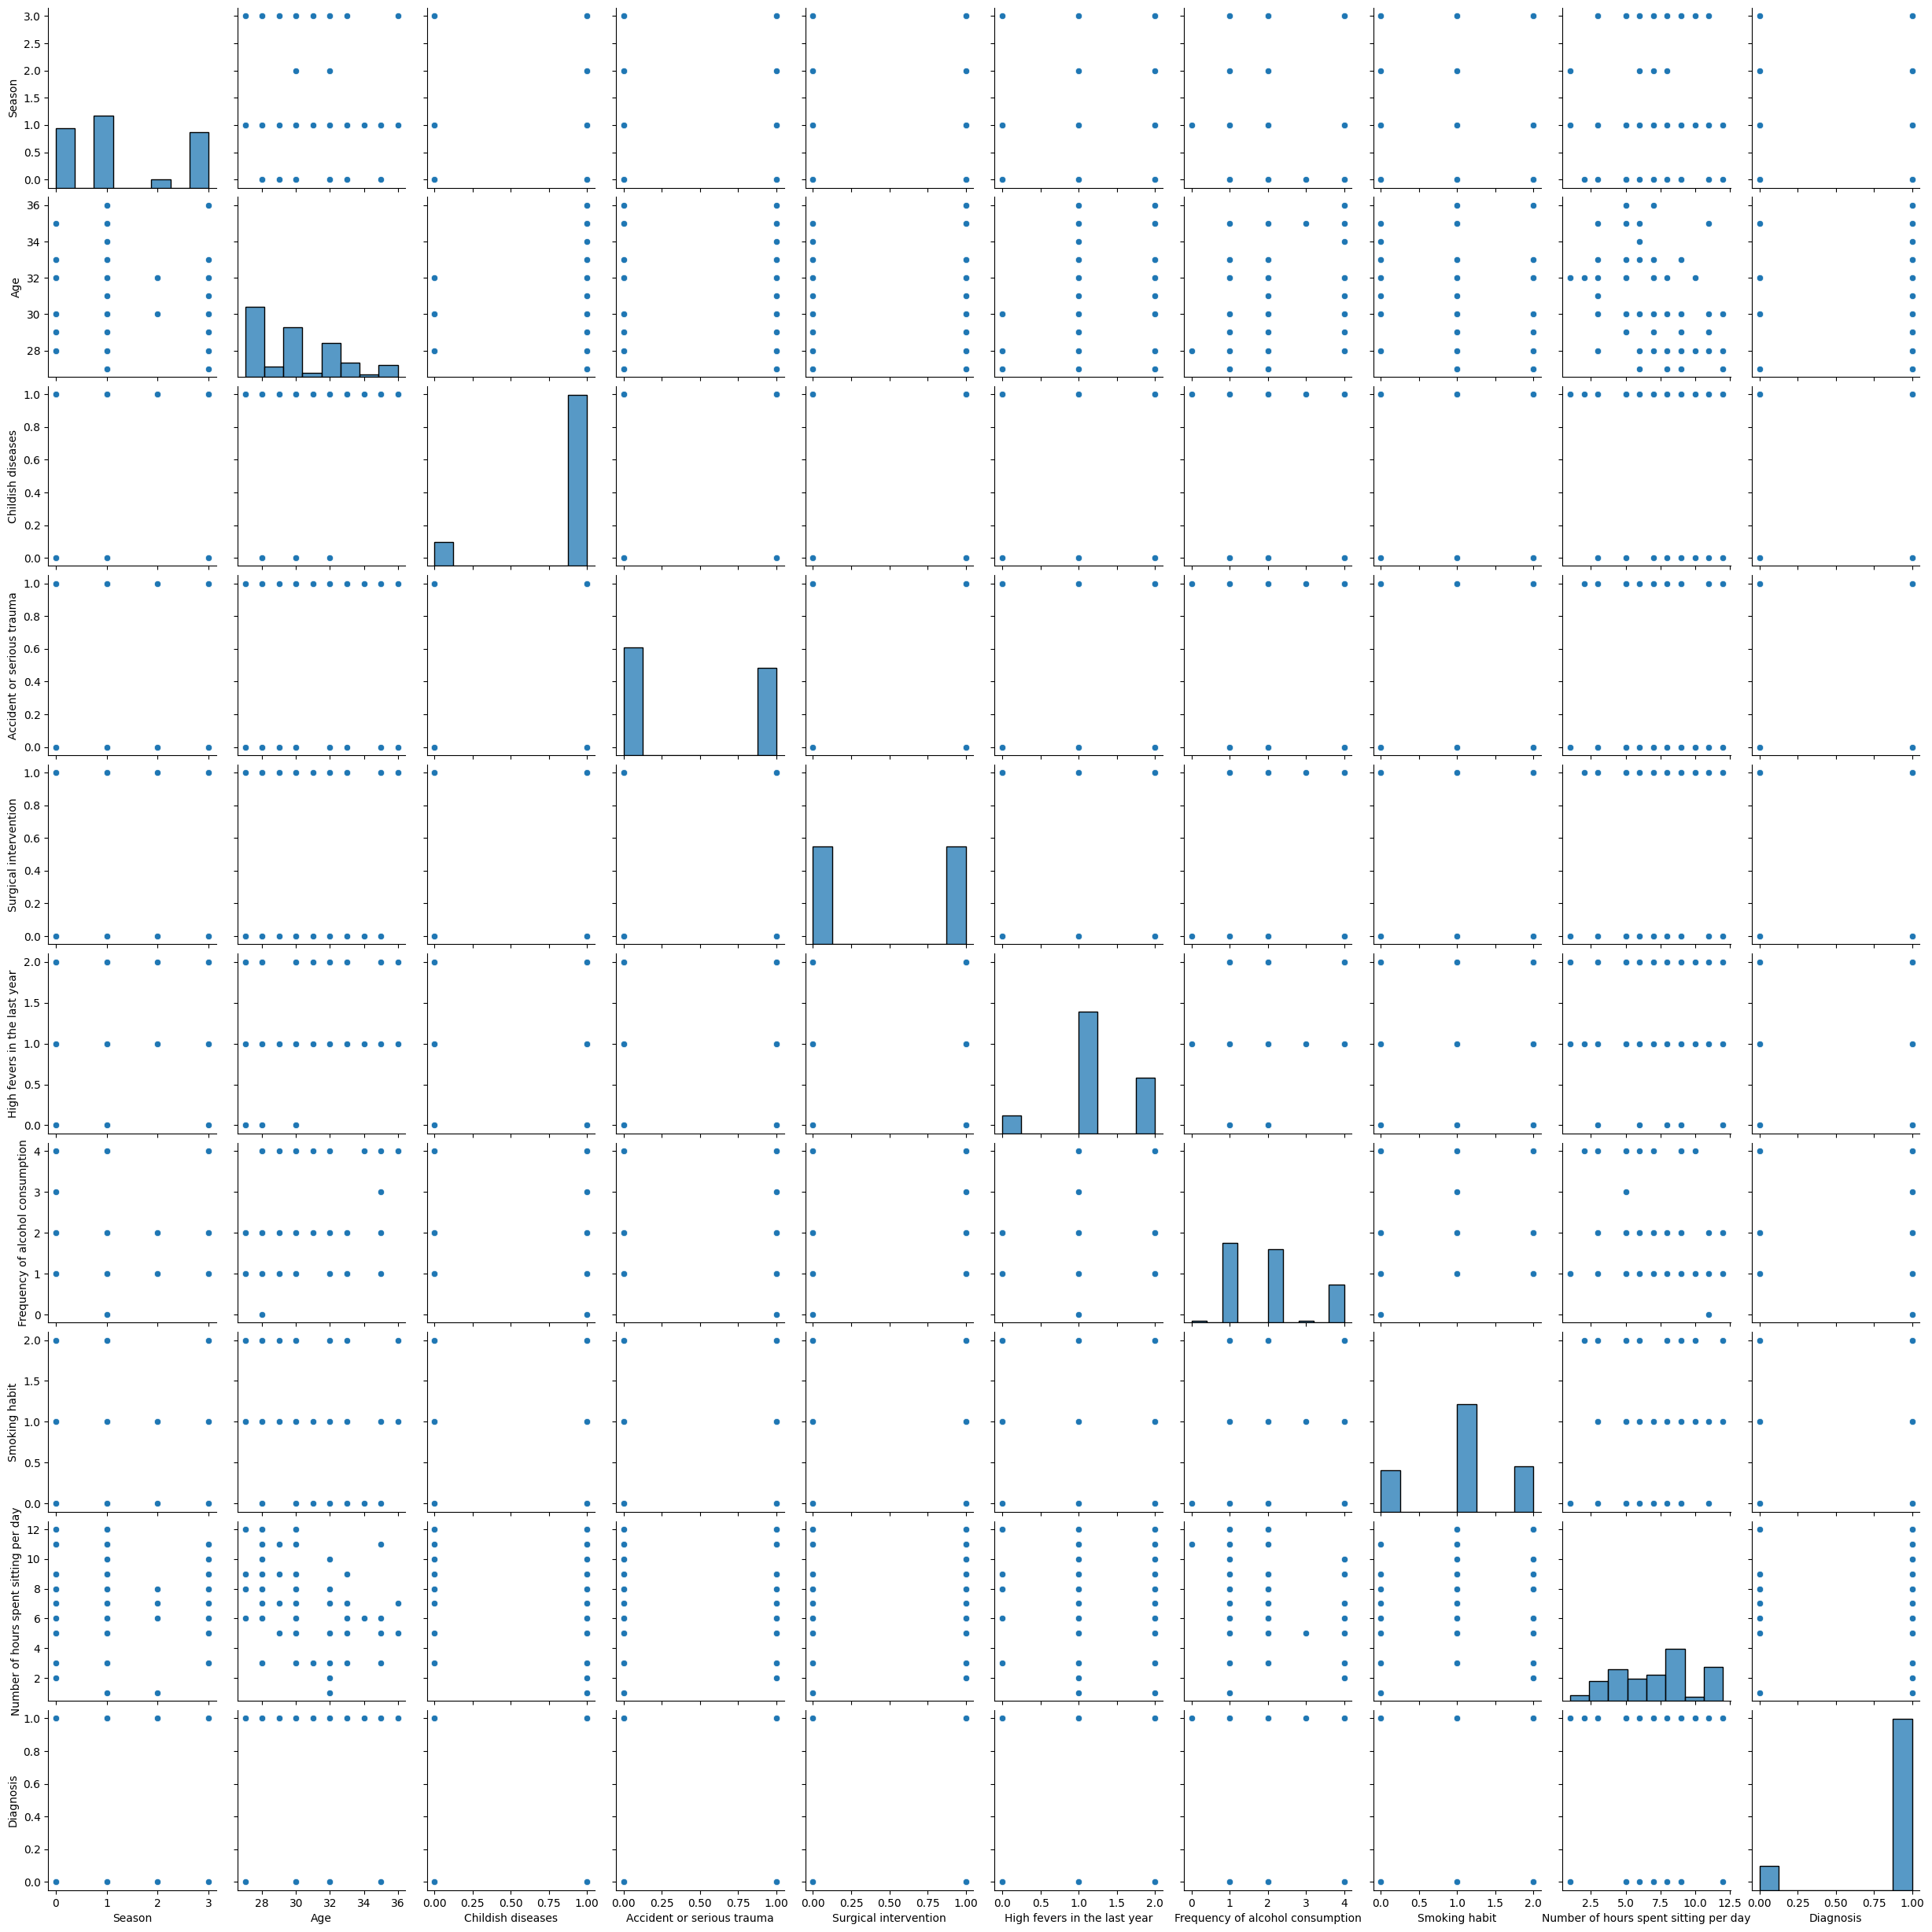

In [75]:
plt.figure(figsize=(20,15))
sns.pairplot(fr)
plt.show()

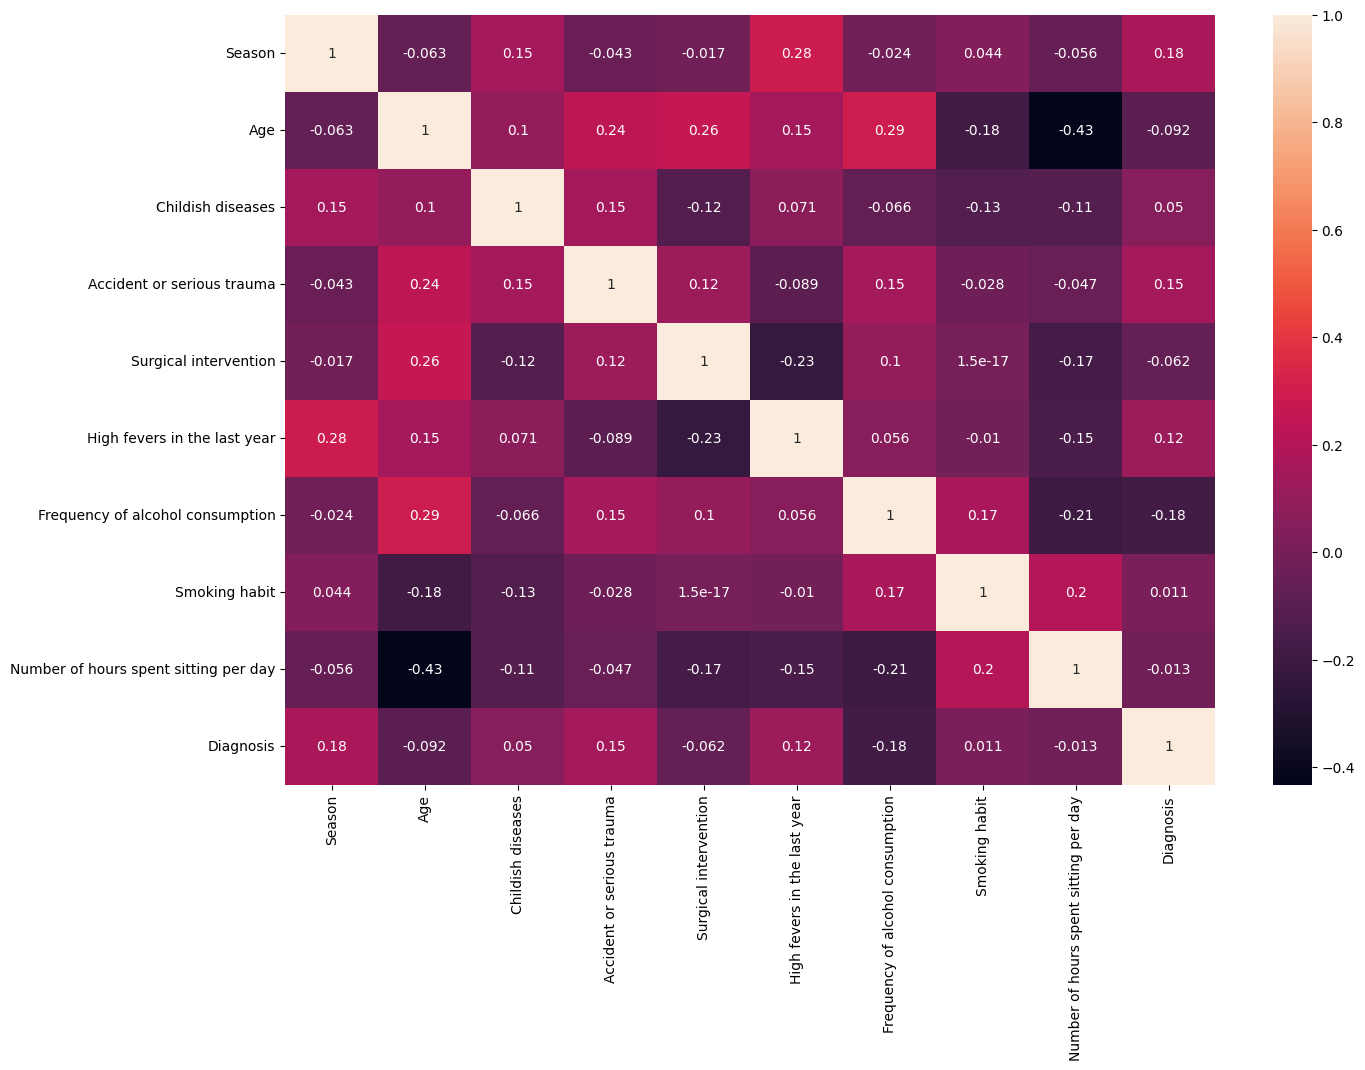

In [76]:
plt.figure(figsize=(15,10))
sns.heatmap(fr.corr(),annot=True)
plt.show()

# Model Prepartion

In [83]:
feature=fr.drop(['Diagnosis'],axis=1)
target=fr['Diagnosis']

In [84]:
x_train,x_test,y_train,y_test=train_test_split(feature,target,test_size=0.15,random_state=42)

In [89]:
lr=LogisticRegression(max_iter=1000,random_state=42)

In [90]:
lr.fit(x_train,y_train,)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [92]:
pre_train=lr.predict(x_train)
acc=accuracy_score(y_train,pre_train)
print("train:",acc)

train: 0.8674698795180723


In [93]:
pre_test=lr.predict(x_test)
acc=accuracy_score(y_test,pre_test)
print("train:",acc)

train: 0.9333333333333333
